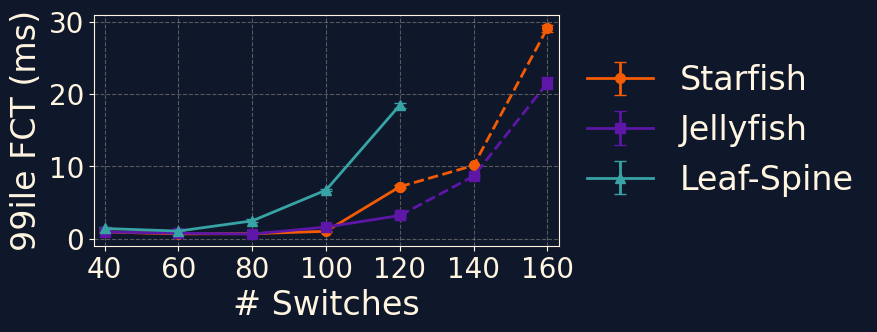

In [18]:
import matplotlib.pyplot as plt
import numpy as np

homedir = "/mnt/mirabelle/az6922_homedir/"

plotlabeldict_supernode = {
    "dringsu2": "Starfish",
    "rrgsu2": "Jellyfish",
    "ls": "Leaf-Spine"
}

plotlabeldict_ring = {
    "dringsu2": "Starfish",
    "rrgsu2": "Jellyfish",
    "leafspine": "Leaf-Spine"
}

plotcolordict = {
    "dringsu2": "#f35b04",
    "rrgsu2": "#5d16a6",
    "ls": "#38a3a5",
    "leafspine": "#38a3a5"
}

plotmarkerdict = {
    "dringsu2": "o",
    "rrgsu2": "s",
    "ls": "^",
    "leafspine": "^"
}

# Dark theme
bg_color = "#0F172A"
text_color = "#FFF5E1"

# Load data
plotdatadict = {}
sumfile = "fct_summary.txt"
with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        p99 = float(tokens[3])
        plotdatadict[outfile] = p99

# supernode
scheme_list_supernode = ["dringsu2", "rrgsu2", "ls"]
sw_list_supernode = [40, 60, 80, 100, 120]
seed_list_supernode = [1, 2, 3, 4, 5]

# ring
scheme_list_ring = ["dringsu2", "rrgsu2", "leafspine"]
sw_list_ring = [120, 140, 160]
seed_list_ring = [1, 2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(6, 3))

# Apply dark background
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# -----------------------------
# Supernode lines
# -----------------------------
for scheme in scheme_list_supernode:
    means, lower_err, upper_err = [], [], []

    for sw in sw_list_supernode:
        fct_list = []
        for seed in seed_list_supernode:
            outfile = f"outfiles/{scheme}_sw{sw}_seed{seed}.out"
            p99 = plotdatadict[outfile]
            fct_list.append(p99)

        mean = np.mean(fct_list)
        means.append(mean)
        lower_err.append(mean - min(fct_list))
        upper_err.append(max(fct_list) - mean)

    ax.errorbar(
        sw_list_supernode,
        means,
        yerr=[lower_err, upper_err],
        label=plotlabeldict_supernode[scheme],
        color=plotcolordict[scheme],
        marker=plotmarkerdict[scheme],
        linestyle='-',
        linewidth=2,
        markersize=7,
        capsize=4
    )

# -----------------------------
# Ring lines
# -----------------------------
for scheme in scheme_list_ring:
    if scheme == "leafspine":
        continue

    means, lower_err, upper_err = [], [], []

    for sw in sw_list_ring:
        fct_list = []
        for seed in seed_list_ring:
            if sw == 120:
                outfile = f"../eval_scale_larger_supernode/outfiles/{scheme}_sw{sw}_seed{seed}.out"
            else:
                outfile = f"outfiles/{scheme}_sw{sw}_seed{seed}.out"

            p99 = plotdatadict[outfile]
            fct_list.append(p99)

        mean = np.mean(fct_list)
        means.append(mean)
        lower_err.append(mean - min(fct_list))
        upper_err.append(max(fct_list) - mean)

    ax.errorbar(
        sw_list_ring,
        means,
        yerr=[lower_err, upper_err],
        color=plotcolordict[scheme],
        marker=plotmarkerdict[scheme],
        linestyle='--',
        linewidth=2,
        markersize=7,
        capsize=4
    )

# Formatting
ax.set_xlabel("# Switches", fontsize=24, color=text_color)
ax.set_ylabel("99ile FCT (ms)", fontsize=24, color=text_color)

ax.tick_params(axis='both', labelsize=20, colors=text_color)

ax.grid(True, axis='both', linestyle='--', alpha=0.3, color=text_color)

ax.set_xticks([40, 60, 80, 100, 120, 140, 160])
ax.set_xticklabels([40, 60, 80, 100, 120, 140, 160])

ax.set_xlim(37, 163)
ax.set_ylim(-1, 31)

# Spine colors
for spine in ax.spines.values():
    spine.set_color(text_color)

# Legend
legend = ax.legend(loc='center right', bbox_to_anchor=(1.7, 0.5), ncol=1, fontsize=24, frameon=False)
for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig("talk_scale_full.pdf", dpi=600, bbox_inches='tight',facecolor=fig.get_facecolor())

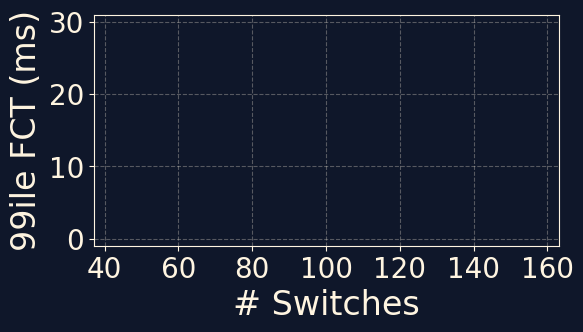

In [19]:
import matplotlib.pyplot as plt
import numpy as np

bg_color = "#0F172A"
text_color = "#FFF5E1"

fig, ax = plt.subplots(figsize=(6, 3))

fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Formatting
ax.set_xlabel("# Switches", fontsize=24, color=text_color)
ax.set_ylabel("99ile FCT (ms)", fontsize=24, color=text_color)

ax.tick_params(axis="both", labelsize=20, colors=text_color)

ax.grid(True, axis="both", linestyle="--", alpha=0.3, color=text_color)

ax.set_xticks([40, 60, 80, 100, 120, 140, 160])
ax.set_xticklabels([40, 60, 80, 100, 120, 140, 160])

# Keep the same empty plot scale
ax.set_xlim(37, 163)
ax.set_ylim(-1, 31)

for spine in ax.spines.values():
    spine.set_color(text_color)

plt.savefig(
    "talk_scale_empty.pdf",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)